In [1]:
from pathlib import Path
import joblib
import sys

sys.path.append('..')
from utils import print_cv_results, draw_pr_curve_from_cv_results, cv_results_to_long

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
from aeon.classification.feature_based import Catch22Classifier
from aeon.regression.feature_based import Catch22Regressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import (GridSearchCV,
                                     cross_validate,
                                     cross_val_predict,
                                     StratifiedKFold,
                                     TunedThresholdClassifierCV)
from sklearn.metrics import (classification_report,
                             PredictionErrorDisplay)

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
?Catch22Classifier

Init signature:
Catch22Classifier(
    features='all',
    catch24=True,
    outlier_norm=True,
    replace_nans=True,
    use_pycatch22=False,
    estimator=None,
    random_state=None,
    n_jobs=1,
    parallel_backend=None,
    class_weight=None,
)
Docstring:     
Canonical Time-series Characteristics (catch22) classifier.

This classifier simply transforms the input data using the Catch22 [1]_
transformer and builds a provided estimator using the transformed data.

Parameters
----------
features : int/str or List of int/str, default="all"
    The Catch22 features to extract by feature index, feature name as a str or as a
    list of names or indices for multiple features. If "all", all features are
    extracted. Valid features are as follows:
        ["DN_HistogramMode_5", "DN_HistogramMode_10",
        "SB_BinaryStats_diff_longstretch0", "DN_OutlierInclude_p_001_mdrmd",
        "DN_OutlierInclude_n_001_mdrmd", "CO_f1ecac", "CO_FirstMin_ac",
        "SP_Summaries_welch_rect_area_

Catch22 classifier/regressor use a Random Forest as default estimator.
We first run the model without hyperparameter tuning on sensible and cross validate, then we tune hyperparameters (we let individual trees to fully develop and manipulate only the number of estimators and max features).

In [6]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)
train_X

array([[[3.4337030e+06, 3.5627470e+06, 3.6783780e+06, ...,
         3.2835000e+04, 2.4195000e+04, 1.5942000e+04]],

       [[1.3375850e+07, 1.3024208e+07, 1.2709883e+07, ...,
         1.0818400e+05, 9.7706000e+04, 8.5139000e+04]],

       [[6.1996510e+06, 6.1155390e+06, 6.0112680e+06, ...,
         3.7329000e+04, 3.2947000e+04, 2.8392000e+04]],

       ...,

       [[2.6042900e+05, 2.9606100e+05, 3.2769800e+05, ...,
         1.8260000e+03, 2.1760000e+03, 2.4170000e+03]],

       [[1.4011070e+06, 1.5475290e+06, 1.6583720e+06, ...,
         4.6690000e+03, 5.2010000e+03, 6.0740000e+03]],

       [[2.5680000e+05, 2.5933100e+05, 2.6278500e+05, ...,
         1.6870000e+04, 1.6140000e+04, 1.5510000e+04]]],
      shape=(850, 1, 100))

## No hyperparameter tuning

### Action

In [7]:
action_scores = ('precision', 'recall', 'f1', 'average_precision')
train_y = train['action']

Good empirical parameters for random forest classifier are `max_features='sqrt'` and good results are often obtained with `max_depth=None` in combination with `min_samples_split=2`, i.e. when fully developing the trees. By default random forest is using bootstraps.

In [8]:
rfc = RandomForestClassifier(max_features='sqrt', n_jobs=-1)
clf = Catch22Classifier(features='all', catch24=True, use_pycatch22=True,
                        estimator=rfc)
clf

,features,'all'
,catch24,True
,outlier_norm,True
,replace_nans,True
,use_pycatch22,True
,estimator,RandomForestC...ier(n_jobs=-1)
,random_state,None
,n_jobs,1
,parallel_backend,None
,class_weight,None
,n_estimators,100


There's no need to normalize Catch22 features because we are using trees.

In [9]:
results = cross_validate(clf, train_X, train_y, scoring=action_scores, n_jobs=-1)
print_cv_results(results)

precision: 0.66 (0.02)
recall: 0.44 (0.04)
f1: 0.53 (0.04)
average_precision: 0.66 (0.04)


### Rating

In [10]:
train_y = train['rating_category']
rating_scores = ('precision_macro', 'recall_macro', 'f1_macro', 'accuracy')

In [11]:
%%capture --no-stdout
results = cross_validate(clf, train_X, train_y, scoring=rating_scores)
print_cv_results(results)

precision_macro: 0.33 (0.03)
recall_macro: 0.3 (0.01)
f1_macro: 0.29 (0.01)
accuracy: 0.45 (0.02)


### Regression

In [12]:
train_y = train['rating']
regression_scores = ('neg_mean_squared_error', 'r2')

Good empirical parameters for random forest regressor are `max_features=1.0` (this is, in fact, the default), i.e. fitting each tree on all features. The rest is the same we saw for classification.

In [13]:
rfr = RandomForestRegressor(max_features=1.0, n_jobs=-1)
regressor = Catch22Regressor(features='all', catch24=True, use_pycatch22=True,
                             estimator=rfr)
regressor

,features,'all'
,catch24,True
,outlier_norm,True
,replace_nans,True
,use_pycatch22,True
,estimator,RandomForestR...sor(n_jobs=-1)
,random_state,None
,n_jobs,1
,parallel_backend,None
,n_estimators,100
,criterion,'squared_error'


In [14]:
results = cross_validate(regressor, train_X, train_y, scoring=regression_scores, n_jobs=-1)
print_cv_results(results)

neg_mean_squared_error: -0.58 (0.08)
r2: 0.27 (0.09)


## Hyperparameters tuning

In [15]:
grid_cv = StratifiedKFold()
cv = StratifiedKFold(shuffle=True, random_state=42)

Remember to tune parameters on the defined cv, but cross validate the final model on a different set of folds, for a less optimistic prediction.

In [16]:
# We can use the same set of parameters on all tasks
param_grid = {
    'estimator__max_features': ('log2', 'sqrt', 1.0),
    'estimator__n_estimators': (10, 50, 100, 200),
}

grid = GridSearchCV(clf,
                    param_grid=param_grid,
                    cv=grid_cv,
                    n_jobs=-1,
                    verbose=2)

In [17]:
def plot_grid_results(results):
    sns.relplot(results, x='param_estimator__n_estimators', y='test_score',
                errorbar='sd',
                hue='param_estimator__max_features',
                kind='line')

### Action

In [18]:
grid.scoring = 'average_precision'
train_y = train['action']

In [19]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.4s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.4s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.4s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.4s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.6s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.6s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=100; total time=

,estimator,Catch22Classi...ycatch22=True)
,param_grid,"{'estimator__max_features': ('log2', ...), 'estimator__n_estimators': (10, ...)}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


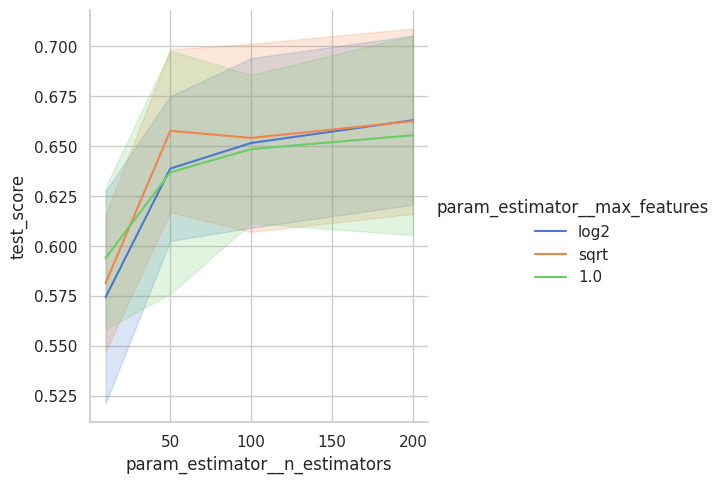

In [20]:
plot_grid_results(cv_results_to_long(grid.cv_results_))

Performance degrades with more than 100 estimators. Number of features has some influence, with models  using all features performing worse, especially on a high number of estimators.
Overall the models are not showing an extreme sensibility to hyperparameters: standard deviation of scores across different folds in greater than differences between different parameters configurations.

In [21]:
print(grid.best_params_)
action_best_estimator = grid.best_estimator_

{'estimator__max_features': 'log2', 'estimator__n_estimators': 200}


In [22]:
grid.best_score_

np.float64(0.6630474660767647)

In [23]:
results = cross_validate(action_best_estimator, train_X, train_y, cv=cv, n_jobs=-1, scoring=action_scores,
                        return_estimator=True,
                         return_indices=True)
print_cv_results(results)

precision: 0.62 (0.06)
recall: 0.42 (0.05)
f1: 0.5 (0.05)
average_precision: 0.63 (0.05)


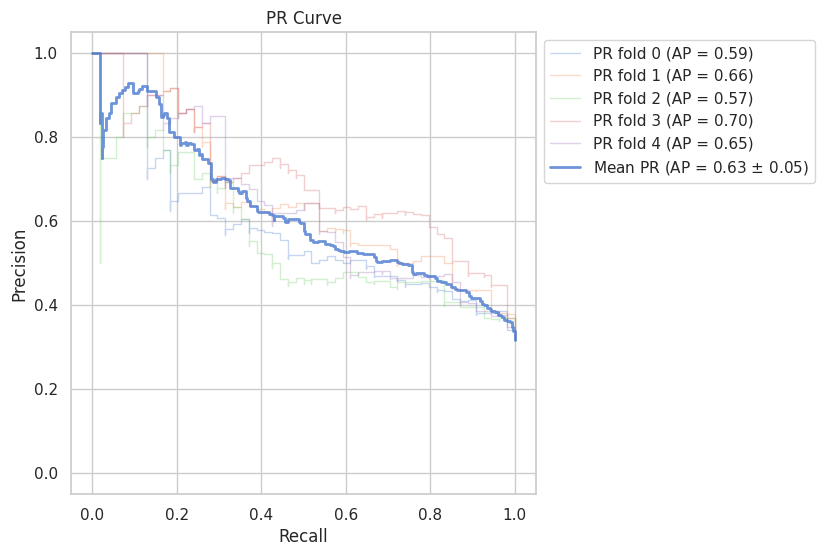

In [24]:
draw_pr_curve_from_cv_results(results, train_X, train_y)

In [25]:
y_pred = action_best_estimator.predict(train_X)
print(classification_report(train_y, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       580
        True       1.00      1.00      1.00       270

    accuracy                           1.00       850
   macro avg       1.00      1.00      1.00       850
weighted avg       1.00      1.00      1.00       850



High training accuracy is not really a symptom of overfitting in RFs

We tune the decision threshold for the classifier for the best F1 score of the positive class.

In [26]:
action_best_estimator = TunedThresholdClassifierCV(action_best_estimator,
                                                   scoring='f1')
action_best_estimator.fit(train_X, train_y)

,estimator,Catch22Classi...ycatch22=True)
,scoring,'f1'
,response_method,'auto'
,thresholds,100
,cv,None
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,n_estimators,200
,criterion,'gini'


In [27]:
print("Best threshold:", action_best_estimator.best_threshold_)
print("Best F1:", action_best_estimator.best_score_)

Best threshold: 0.3228282828282828
Best F1: 0.6187230305934391


### Rating

In [28]:
grid.scoring = 'f1_macro'
train_y = train['rating_category']

In [29]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.4s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.4s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.6s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.6s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.6s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.7s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.7s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.6s
[CV] END estimator__max_features=log2, estimator__n_estimators=100; total time=

,estimator,Catch22Classi...ycatch22=True)
,param_grid,"{'estimator__max_features': ('log2', ...), 'estimator__n_estimators': (10, ...)}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


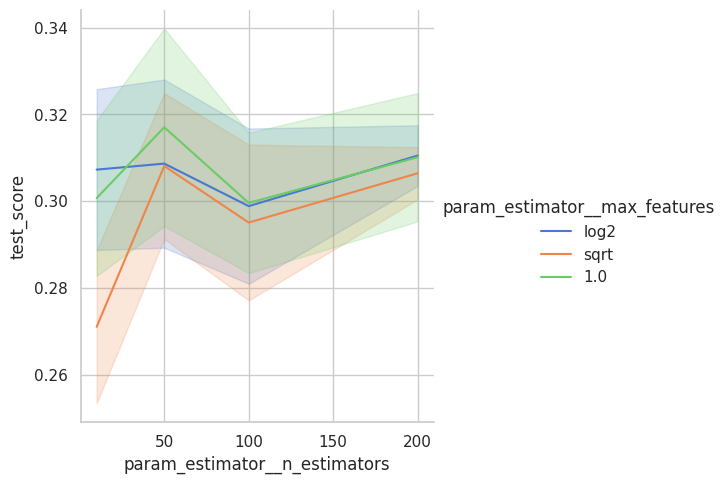

In [30]:
plot_grid_results(cv_results_to_long(grid.cv_results_))

In [31]:
rating_best_estimator = grid.best_estimator_
print(grid.best_params_)

{'estimator__max_features': 1.0, 'estimator__n_estimators': 50}


In this case we can see that variance between folds is decreasing according to the number of estimators.

In [32]:
grid.best_score_

np.float64(0.3170470230983208)

In [33]:
%%capture --no-stdout
results = cross_validate(rating_best_estimator, train_X, train_y, cv=cv, n_jobs=-1, scoring=rating_scores)
print_cv_results(results)

precision_macro: 0.32 (0.03)
recall_macro: 0.3 (0.02)
f1_macro: 0.3 (0.02)
accuracy: 0.45 (0.03)


/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

### Regression

In [34]:
grid_reg = GridSearchCV(regressor,
                    param_grid=param_grid,
                    n_jobs=-1,
                    verbose=2,
                    scoring='r2')
train_y = train['rating']

In [35]:
grid_reg

,estimator,Catch22Regres...ycatch22=True)
,param_grid,"{'estimator__max_features': ('log2', ...), 'estimator__n_estimators': (10, ...)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [36]:
%%time
grid_reg.fit(train_X, train_y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.5s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.6s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.7s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.7s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.8s
[CV] END estimator__max_features=log2, estimator__n_estimators=10; total time=   0.8s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.6s
[CV] END estimator__max_features=log2, estimator__n_estimators=50; total time=   0.7s
[CV] END estimator__max_features=log2, estimator__n_estimators=100; total time=

,estimator,Catch22Regres...ycatch22=True)
,param_grid,"{'estimator__max_features': ('log2', ...), 'estimator__n_estimators': (10, ...)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


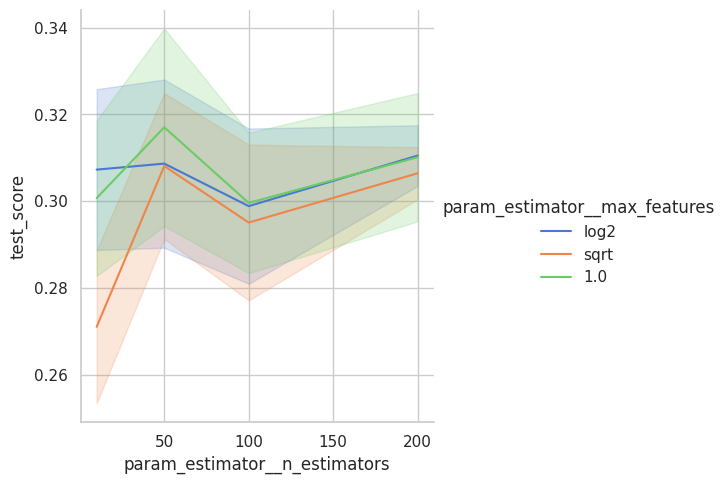

In [37]:
plot_grid_results(cv_results_to_long(grid.cv_results_))

In [38]:
print(grid.best_params_)
print(grid.best_score_)

{'estimator__max_features': 1.0, 'estimator__n_estimators': 50}
0.3170470230983208


We prefer an estimator with a slightly lower f1 score and standard deviation.

In [39]:
regressor.estimator.set_params(
    max_features='log2',
    n_estimators=200
)

regression_best_estimator = regressor
regression_best_estimator.fit(train_X, train_y)

,features,'all'
,catch24,True
,outlier_norm,True
,replace_nans,True
,use_pycatch22,True
,estimator,"RandomForestR...00, n_jobs=-1)"
,random_state,None
,n_jobs,1
,parallel_backend,None
,n_estimators,200
,criterion,'squared_error'


In [40]:
results = cross_validate(regression_best_estimator, train_X, train_y, n_jobs=-1,
                         scoring=regression_scores)
print_cv_results(results)

neg_mean_squared_error: -0.57 (0.08)
r2: 0.28 (0.09)


In [41]:
y_pred = cross_val_predict(regression_best_estimator, train_X, train_y)

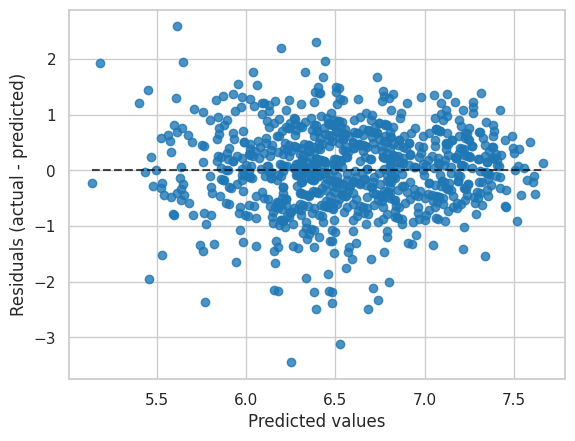

In [42]:
PredictionErrorDisplay.from_predictions(train_y, y_pred)

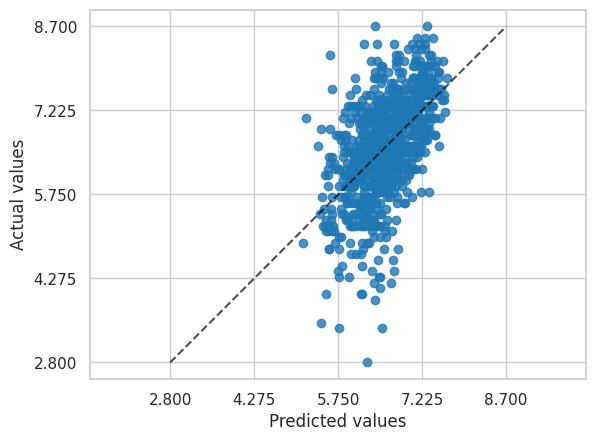

In [43]:
PredictionErrorDisplay.from_predictions(train_y, y_pred, kind='actual_vs_predicted')

In [44]:
models_dir = data_dir / 'models'
with open(models_dir / 'c22_action.pkl', 'wb') as outfile:
    joblib.dump(action_best_estimator ,outfile, protocol=5)
with open(models_dir / 'c22_rating.pkl', 'wb') as outfile:
    joblib.dump(rating_best_estimator ,outfile, protocol=5)
with open(models_dir / 'c22_regressor.pkl', 'wb') as outfile:
    joblib.dump(regression_best_estimator ,outfile, protocol=5)